[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/KalininGroup/camm_hackathon/blob/k4my4r/docs/day_5_11212025/2025_Ising_CAMM_hackaton.ipynb)


# **Ising: A Hackathon Toy Model**

- The Ising model is by **Rama Vasudevan**, vasudevanrk@ornl.gov

- This model has been used in several of our publications, including https://pubs.aip.org/aip/jap/article/128/16/164304/568362/Exploration-of-lattice-Hamiltonians-for-functional

# 2D Ising Model Simulation

This notebook simulates a 2D Ising model on an $(N \times N$) square lattice using the Metropolis Monte Carlo algorithm. Each lattice site carries a spin $(s_{ij} = \pm 1$). Spins interact through a user-defined $(5 \times 5$) coupling matrix \(J_{pq}\), which specifies interaction strengths for neighbors within this radius.

The energy of a configuration is computed using the generalized Ising Hamiltonian:

$$
E = -\sum_{i,j} \sum_{p,q} J_{pq} \, s_{i,j} \, s_{i+p,j+q}
$$

with periodic boundary conditions.  
For $(J_{pq} > 0$), aligned spins lower the energy (ferromagnetic).  
For $(J_{pq} < 0$), anti-aligned spins lower the energy (antiferromagnetic).

Spin updates follow the Metropolis rule with acceptance probability:

$$
P(\Delta E) = \min\left(1, e^{-\Delta E / T}\right)
$$

where \(T\) is the reduced temperature.

The simulation records

- energy

- magnetization,

$$
M = \sum_{i,j} s_{i,j},
$$

- thermodynamic quantities using fluctuation formulas

$$
C = \frac{\langle E^2 \rangle - \langle E \rangle^2}{T^2}, \qquad
\chi = \frac{\langle M^2 \rangle - \langle M \rangle^2}{T}.
$$



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.random import rand

from tqdm import tqdm
from typing import Union, Dict, Callable

import math
import time

import imageio.v2 as imageio

In [2]:
#@title Square Ising Model

class IsingSim():

  """This class performs Ising model simulations on a 2D grid. Interaction parameters are given by a matrix at each lattice site.
  Field dependence is not supported at this time but will be in due course. The simulator outputs configurations after equlibrium
  as well as the trajectories, if specifically requested.
  Inputs:
    - N : (integer) - Size of lattice will be N^2. Only 2D square lattice is supported at this stage.
    - J_mat: (numpy matrix of shape(5,5)) - entries being floats for interaction parameters. Self-interaction (middle element of matrix)=0.
    - T: (float) - Reduced temperature for simulation
    - save_trajectories: (Boolean) - whether to save trajectories, or only final state. Default False.
    - eqSteps: (integer) number of Monte-Carlo steps for equlibration before simulation starts. Default 750. AKA 'burn-in'.
    - mcSteps: (integer) number of Monte-Carlo for simulation. Default 750.
  Outputs: Several outputs are available, including trajectories (if called), configurations (i.e., the 2D states) and configurations histograms.
  These can be obtained by calling methods self.configurations(), self.histograms() and self.trajectories()"""

  def __init__(self, N = 40,
               J_mat = None,
               T = 2.7,
               save_trajectories = False,
               eqSteps = 750,
               mcSteps = 750,
               random_init = False):
    self.N = N

    #If no J matrix is provided we default to isotropic J interaction with NN with value 0.5
    if np.array(J_mat).all() == None:
      J_mat = np.zeros((5,5))
      J_mat[1,2] = J_mat[2,1] = J_mat[2,3] = J_mat[3,2] = 0.5 #Defaulting to 0.5 for NN, all others zeroed out.

    self.J_mat = J_mat

    self.save_trajectories = save_trajectories
    self.eqSteps = eqSteps
    self.mcSteps = mcSteps
    self.config = self.initialState(random = random_init)
    self.T = T

  def initialState(self, random = False):
    ''' Generates a lattice with spin configurations drawn randomly [-1 or 1] if random=True
    Else, the lattice is generated with all sites = 1 '''

    if isinstance(random, bool):
      if random==True: state = 2*np.random.randint(2, size=(self.N,self.N))-1
      else: state = np.ones([self.N,self.N])
    elif isinstance(random, int):
      state = np.ones([self.N,self.N])
      state.fill(np.sign(random+0.1))
    else:
      raise TypeError('random_init should be either booleal, or 1, or -1')

    return state

  def mcmove(self, config):
    '''Monte Carlo move using Metropolis algorithm '''

    M = 5 #neighborhood size (M^2). Do not change!
    beta = 1.0/self.T

    for i in range(self.N):
      for j in range(self.N):
        J_mat = self.J_mat
        cost = 0.0
        s =  np.copy(config[i, j])

        for p in range(-int(M/2), int(M/2)+1, 1):
          for q in range(-int(M/2), int(M/2)+1, 1):
            cost += 2 * J_mat[int(M/2)+p, int(M/2)+q] * config[(i+p)%self.N,(j+q)%self.N] * config[i,j]

        if cost < 0:
          s *= -1
        elif rand() < np.exp(-cost*beta):
          s *= -1
        config[i, j] = s
    return config


  def calcEnergy(self, config):
    '''Returns the energy of the current configuration'''
    M = 5
    energy = 0.0
    for i in range(len(config)):
      for j in range(len(config)):
        J_mat = self.J_mat #otherwise, no

        s = config[i,j]
        for p in range(-int(M/2), int(M/2)+1, 1):
          for q in range(-int(M/2), int(M/2)+1, 1):
            energy += -J_mat[int(M/2)+p, int(M/2)+q] * config[(i+p)%self.N,(j+q)%self.N] * config[i,j]

    return energy/4.0


  def calcMag(self, config):
    '''Magnetization of a given configuration'''
    return np.sum(config)

  def calcAbsMag(self, config):
    ''' Absolute Magnetization of a given configuration'''
    return (np.abs(np.sum(config)))*1.0

  def performIsingSim(self):

    E1, M1, E2, M2 = 0.0,0.0,0.0,0.0    #These are all the average properties of all MC steps used
    E_traj, M_traj = np.zeros(self.mcSteps), np.zeros(self.mcSteps)

    config = np.copy(self.config)
    T = self.T
    if self.save_trajectories: config_mat = np.zeros([self.mcSteps,self.N,self.N])   #Saving all the configurations


    print('\n---Performing Equlibration---\n')
    for i in tqdm(range(self.eqSteps)):
        config = self.mcmove(config)

    print('\n---Finished...\n----Performing MC Moves----\n')
    for j in tqdm(range(self.mcSteps)):
        config = self.mcmove(config)
        Ene, Mag = self.calcEnergy(config), self.calcAbsMag(config)
        E_traj[j] = self.calcEnergy(config)/(self.N*self.N)
        M_traj[j] = self.calcAbsMag(config)/(self.N*self.N)

        E1 = E1 + Ene
        M1 = M1 + Mag
        M2 = M2 + Mag * Mag
        E2 = E2 + Ene * Ene

        if self.save_trajectories: config_mat[j] = config

    print('Completed. Saving')
    Energy = E1 / (self.mcSteps * self.N * self.N)
    Magnetization = M1 / (self.mcSteps * self.N * self.N)
    n1, n2  = 1.0/(self.mcSteps*self.N*self.N), 1.0/(self.mcSteps*self.mcSteps*self.N*self.N)
    iT = 1.0/self.T
    iT2 = iT*iT
    SpecificHeat = (n1*E2 - n2*E1*E1)*iT2
    Susceptibility = (n1*M2 - n2*M1*M1)*iT
    # SpecificHeat = (E2 / self.mcSteps - E1 * E1 / (self.mcSteps * self.mcSteps)) / (self.N * self.T * self.T)
    # Susceptibility = (M2 / self.mcSteps - M1 * M1 / (self.mcSteps * self.mcSteps)) / (self.N * self.T)

    self.config = config


    if self.save_trajectories:
      results_dict = {'config': config_mat, 'Energy': Energy, 'Magnetization': Magnetization,
      'SpecificHeat': SpecificHeat, 'Susceptibility': Susceptibility, 'E_traj': E_traj,
      'M_traj': M_traj,
      }
    else:
      results_dict = {'Energy': Energy, 'Magnetization': Magnetization,
      'SpecificHeat': SpecificHeat, 'Susceptibility': Susceptibility,
      'E_traj': E_traj, 'M_traj': M_traj,}

    self.results = results_dict

    return 'Completed simulation'


---Performing Equlibration---



100%|██████████| 100/100 [00:04<00:00, 24.81it/s]



---Finished...
----Performing MC Moves----



100%|██████████| 100/100 [00:08<00:00, 12.36it/s]


Completed. Saving


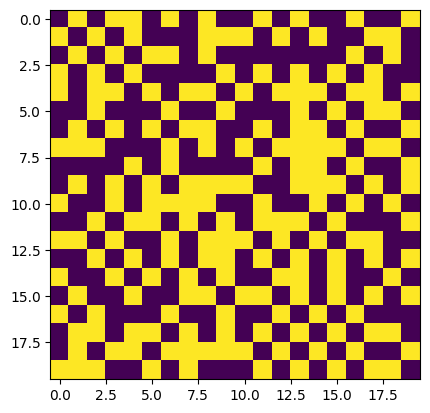

In [3]:
results_dict = {}
approx_ys = np.zeros(1)
time_eval = np.zeros(1)

J_mat = np.array([[0,0,0,0,0],
                  [0,0,-2,0,0],
                  [0,-2,0,-2,0],
                  [0,0,-2,0,0],
                  [0,0,0,0,0]])

start_time = time.time()

np.random.seed(0)
sq_sim = IsingSim(N = 20, J_mat = J_mat, T = 5.7, save_trajectories=True, eqSteps = 100, mcSteps = 100)  # Intializing the object
sq_sim.performIsingSim()   # Running the sim
end_time = time.time()
time_eval = end_time-start_time

results_dict[0] = {'sim': sq_sim.results,}
approx_ys[0] = results_dict[0]['sim']['SpecificHeat']
plt.imshow(results_dict[0]['sim']['config'][-1])
plt.show()

## Example 1: "Antiferroelectric" state melting

In [45]:
#@title
tt = np.linspace(1,5,5)
Jc = -1

J_mat = np.array([[0,0,0,0,0],
                  [0,0, Jc,0,0],
                  [0,Jc,0,Jc,0],
                  [0,0,Jc,0,0],
                  [0,0,0,0,0]])

traj = {}
for t in tt:
  np.random.seed(0)
  sq_sim = IsingSim(N = 20, J_mat = J_mat, T = t, save_trajectories=True, eqSteps = 100, mcSteps = 100)  # Intializing the object
  sq_sim.performIsingSim()   # Running the sim
  end_time = time.time()
  time_eval = end_time-start_time

  traj[t] = sq_sim.results
  # plt.imshow(traj[t]['config'][-1])
  # plt.show()


---Performing Equlibration---



100%|██████████| 100/100 [00:01<00:00, 65.50it/s]



---Finished...
----Performing MC Moves----



100%|██████████| 100/100 [00:04<00:00, 24.78it/s]


Completed. Saving

---Performing Equlibration---



...

Completed. Saving

---Performing Equlibration---



100%|██████████| 100/100 [00:01<00:00, 65.72it/s]



---Finished...
----Performing MC Moves----



100%|██████████| 100/100 [00:03<00:00, 25.00it/s]

Completed. Saving


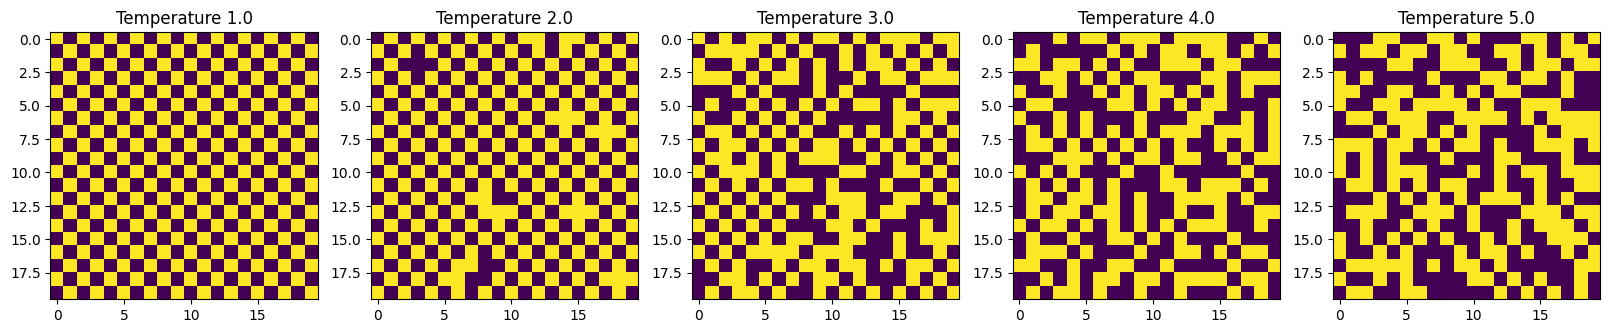

In [46]:
fig, ax = plt.subplots(1, len(tt), figsize=(4*len(tt),4))

for i in range(len(tt)):
  ax[i].imshow(traj[tt[i]]['config'][-1], vmin=0, vmax=1)
  ax[i].set_title(f'Temperature {tt[i]}')

Text(0.5, 0, 'Temperature')

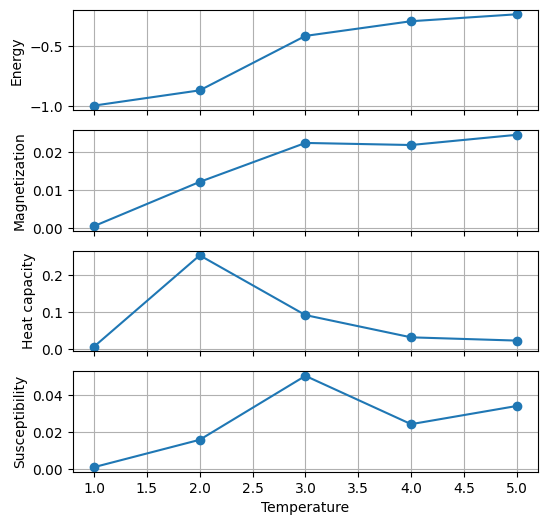

In [6]:
energy = [traj[tt[i]]['Energy'] for i in range(len(tt))]
magnetization = [traj[tt[i]]['Magnetization'] for i in range(len(tt))]
specific_heat = [traj[tt[i]]['SpecificHeat'] for i in range(len(tt))]
susceptibility = [traj[tt[i]]['Susceptibility'] for i in range(len(tt))]

fig, ax = plt.subplots(4, 1, figsize=(6, 6), sharex=True)

ax[0].plot(tt, energy, 'o-')
ax[0].set_ylabel('Energy')
ax[1].plot(tt, magnetization, 'o-')
ax[1].set_ylabel('Magnetization')
ax[2].plot(tt, specific_heat, 'o-')
ax[2].set_ylabel('Heat capacity')
ax[3].plot(tt, susceptibility, 'o-')
ax[3].set_ylabel('Susceptibility')
for ax_ in ax:
  ax_.grid()

ax[3].set_xlabel('Temperature')

In [7]:
traj[tt[i]]['Energy']

np.float64(-0.2288)

In [8]:
tt

array([1., 2., 3., 4., 5.])

## Example 2: "Ferroelectric" state melting

In [9]:
#@title

tt = np.linspace(1,5,5)
Jc = 1

J_mat = np.array([[0,0,0,0,0],
                  [0,0, Jc,0,0],
                  [0,Jc,0,Jc,0],
                  [0,0,Jc,0,0],
                  [0,0,0,0,0]])

traj = {}
for t in tt:
  np.random.seed(0)
  sq_sim = IsingSim(N = 20, J_mat = J_mat, T = t, save_trajectories=True, eqSteps = 100, mcSteps = 100, random_init=False)  # Intializing the object
  sq_sim.performIsingSim()   # Running the sim
  end_time = time.time()
  time_eval = end_time-start_time

  traj[t] = sq_sim.results


---Performing Equlibration---



100%|██████████| 100/100 [00:02<00:00, 46.05it/s]



---Finished...
----Performing MC Moves----



100%|██████████| 100/100 [00:04<00:00, 22.30it/s]


Completed. Saving

---Performing Equlibration---



...

Completed. Saving

---Performing Equlibration---



100%|██████████| 100/100 [00:01<00:00, 65.53it/s]



---Finished...
----Performing MC Moves----



100%|██████████| 100/100 [00:05<00:00, 19.15it/s]

Completed. Saving


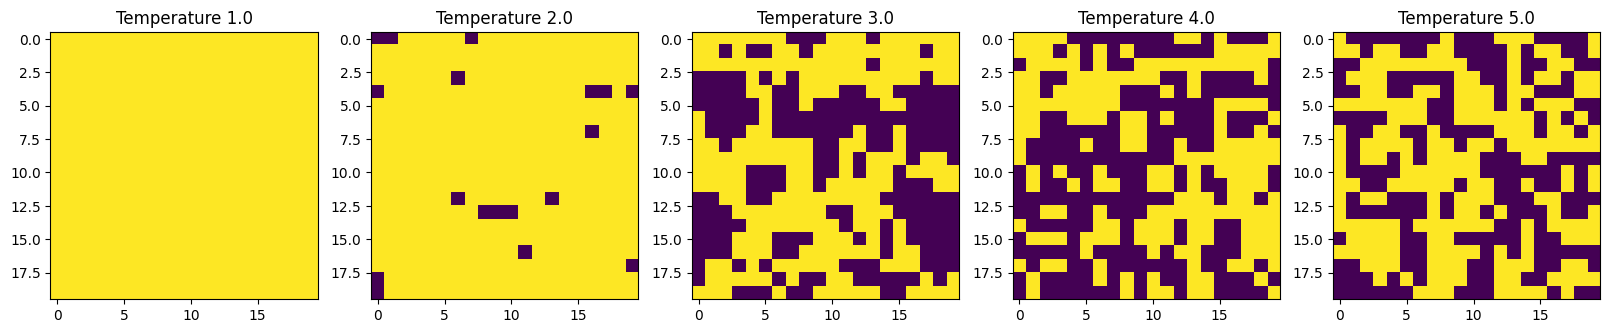

In [10]:
fig, ax = plt.subplots(1, len(tt), figsize=(4*len(tt),4))

for i in range(len(tt)):
  ax[i].imshow(traj[tt[i]]['config'][-1], vmin=0, vmax=1)
  ax[i].set_title(f'Temperature {tt[i]}')

Text(0.5, 0, 'Temperature')

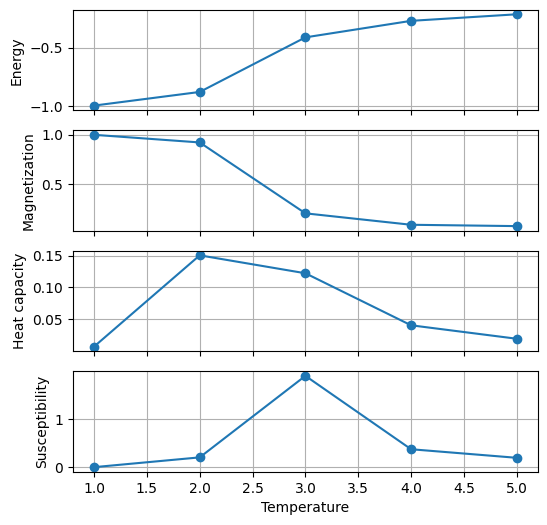

In [11]:
energy = [traj[tt[i]]['Energy'] for i in range(len(tt))]
magnetization = [traj[tt[i]]['Magnetization'] for i in range(len(tt))]
specific_heat = [traj[tt[i]]['SpecificHeat'] for i in range(len(tt))]
susceptibility = [traj[tt[i]]['Susceptibility'] for i in range(len(tt))]

fig, ax = plt.subplots(4, 1, figsize=(6, 6), sharex=True)

ax[0].plot(tt, energy, 'o-')
ax[0].set_ylabel('Energy')
ax[1].plot(tt, magnetization, 'o-')
ax[1].set_ylabel('Magnetization')
ax[2].plot(tt, specific_heat, 'o-')
ax[2].set_ylabel('Heat capacity')
ax[3].plot(tt, susceptibility, 'o-')
ax[3].set_ylabel('Susceptibility')
for ax_ in ax:
  ax_.grid()

ax[3].set_xlabel('Temperature')

## Example 3: Coupling constant grid search

In [12]:
jj = np.linspace(-4,4,10)


traj = {}
for Jc in jj:
  np.random.seed(0)

  J_mat = np.array([[0,0,0,0,0],
                  [0,0, Jc,0,0],
                  [0,Jc,0,Jc,0],
                  [0,0,Jc,0,0],
                  [0,0,0,0,0]])

  sq_sim = IsingSim(N = 20, J_mat = J_mat, T = 4.7, save_trajectories=True, eqSteps = 100, mcSteps = 100, random_init=True)  # Intializing the object
  sq_sim.performIsingSim()   # Running the sim



  traj[Jc] = sq_sim.results


---Performing Equlibration---



100%|██████████| 100/100 [00:01<00:00, 64.22it/s]



---Finished...
----Performing MC Moves----



100%|██████████| 100/100 [00:04<00:00, 22.42it/s]


Completed. Saving

---Performing Equlibration---



...

Completed. Saving

---Performing Equlibration---



100%|██████████| 100/100 [00:02<00:00, 38.71it/s]



---Finished...
----Performing MC Moves----



100%|██████████| 100/100 [00:04<00:00, 23.56it/s]

Completed. Saving


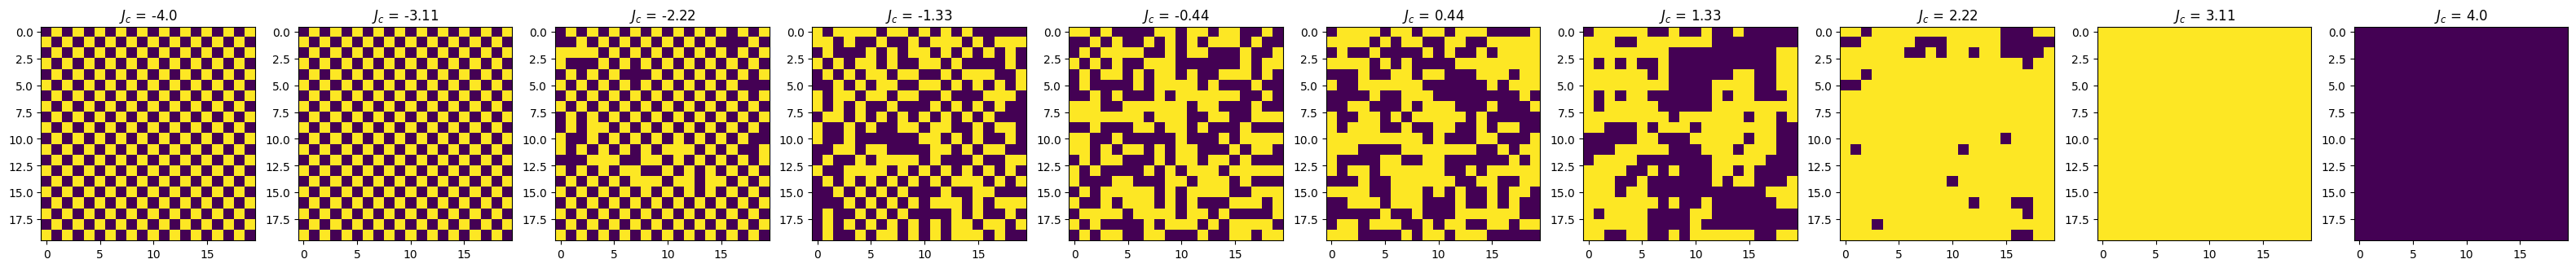

In [13]:
fig, ax = plt.subplots(1, len(jj), figsize=(4*len(jj),4))

for i in range(len(jj)):
  ax[i].imshow(traj[jj[i]]['config'][-1], vmin=0, vmax=1)
  ax[i].set_title(f'$J_c$ = {round(jj[i],2)}')

Text(0.5, 0, '$J_c$')

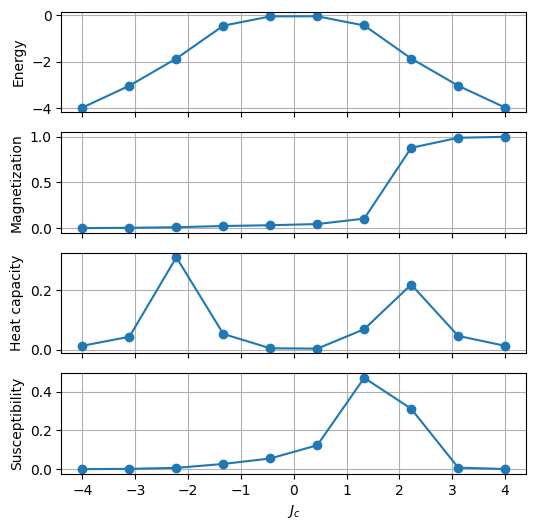

In [14]:
energy = [traj[jj[i]]['Energy'] for i in range(len(jj))]
magnetization = [traj[jj[i]]['Magnetization'] for i in range(len(jj))]
specific_heat = [traj[jj[i]]['SpecificHeat'] for i in range(len(jj))]
susceptibility = [traj[jj[i]]['Susceptibility'] for i in range(len(jj))]

fig, ax = plt.subplots(4, 1, figsize=(6, 6), sharex=True)

ax[0].plot(jj, energy, 'o-')
ax[0].set_ylabel('Energy')
ax[1].plot(jj, magnetization, 'o-')
ax[1].set_ylabel('Magnetization')
ax[2].plot(jj, specific_heat, 'o-')
ax[2].set_ylabel('Heat capacity')
ax[3].plot(jj, susceptibility, 'o-')
ax[3].set_ylabel('Susceptibility')
for ax_ in ax:
  ax_.grid()

ax[3].set_xlabel('$J_c$')

## Example 4: add next-nearest-neibours




---Performing Equlibration---



100%|██████████| 100/100 [00:01<00:00, 70.72it/s]



---Finished...
----Performing MC Moves----



100%|██████████| 100/100 [00:04<00:00, 22.61it/s]


Completed. Saving


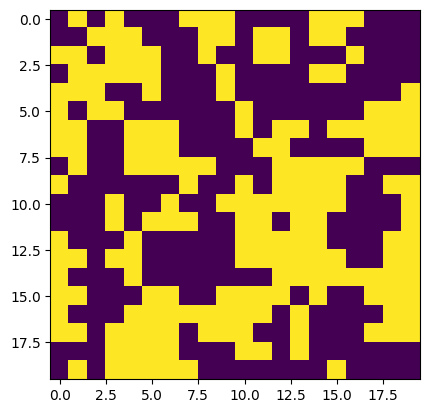

In [15]:
results_dict = {}
approx_ys = np.zeros(1)
time_eval = np.zeros(1)

Jc = 1
Js = 0.5

J_mat = np.array([[0,  0,  0,  0,  0],
                  [0,  Js, Jc, Js, 0],
                  [0,  Jc, 0,  Jc, 0],
                  [0,  Js, Jc, Js, 0],
                  [0,  0,  0,  0,  0]])

start_time = time.time()

np.random.seed(0)
sq_sim = IsingSim(N = 20, J_mat = J_mat, T = 5.7, save_trajectories=True, eqSteps = 100, mcSteps = 100)  # Intializing the object
sq_sim.performIsingSim()   # Running the sim
end_time = time.time()
time_eval = end_time-start_time

results_dict[0] = {'sim': sq_sim.results,}
approx_ys[0] = results_dict[0]['sim']['SpecificHeat']
plt.imshow(results_dict[0]['sim']['config'][-1])
plt.show()

In [16]:
j_resolution= 30

energy_matrix         = np.zeros((j_resolution,j_resolution))
magnetization_matrix  = np.zeros((j_resolution,j_resolution))
h_capacity_matrix     = np.zeros((j_resolution,j_resolution))
susceptibility_matrix = np.zeros((j_resolution,j_resolution))

for i,Jc in enumerate(np.linspace(-4, 4, j_resolution)):
  for j,Js in enumerate(np.linspace(-4, 4, j_resolution)):

    J_mat = np.array([[0,  0,  0,  0,  0],
                     [0,  Js, Jc, Js, 0],
                     [0,  Jc, 0,  Jc, 0],
                     [0,  Js, Jc, Js, 0],
                     [0,  0,  0,  0,  0]])

    sq_sim = IsingSim(N = 7, J_mat = J_mat, T = 4.7, save_trajectories=False, eqSteps = 20, mcSteps = 20, random_init=False)  # Intializing the object
    sq_sim.performIsingSim()   # Running the sim

    energy_matrix[i,j]         = sq_sim.results['Energy']
    magnetization_matrix[i,j]  = sq_sim.results['Magnetization']
    h_capacity_matrix[i,j]     = sq_sim.results['SpecificHeat']
    susceptibility_matrix[i,j] = sq_sim.results['Susceptibility']





---Performing Equlibration---



100%|██████████| 20/20 [00:00<00:00, 322.64it/s]



---Finished...
----Performing MC Moves----



100%|██████████| 20/20 [00:00<00:00, 123.68it/s]


Completed. Saving

---Performing Equlibration---



...

Completed. Saving

---Performing Equlibration---



100%|██████████| 20/20 [00:00<00:00, 268.99it/s]



---Finished...
----Performing MC Moves----



100%|██████████| 20/20 [00:00<00:00, 101.94it/s]

Completed. Saving


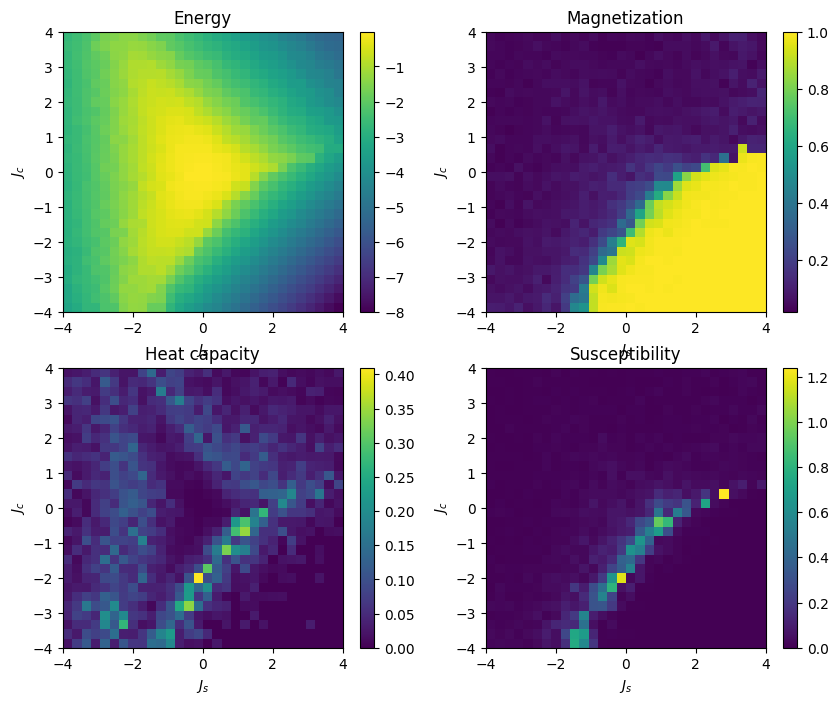

In [17]:
mtrx = [energy_matrix, magnetization_matrix, h_capacity_matrix, susceptibility_matrix]
titles = ['Energy', 'Magnetization', 'Heat capacity', 'Susceptibility']

fig, ax = plt.subplots(2,2, figsize=(10,8))

for i, ax_ in enumerate(ax.flatten()):
  im= ax_.imshow(mtrx[i], extent=[-4,4,-4,4])
  plt.colorbar(im)
  ax_.set_ylabel('$J_c$')
  ax_.set_xlabel('$J_s$')
  ax_.set_title(titles[i])



# **Triangular Ising model**

In [42]:
#@title Triangular Ising model
import numpy as np
from numpy.random import rand
import matplotlib.pyplot as plt
from tqdm import tqdm
from matplotlib import colors
import matplotlib.patches as mpatches
from matplotlib.collections import PatchCollection


class Tri_IsingSim():

  """This class performs Ising model simulations on a 2D grid. Interaction parameters are given by a matrix at each lattice site.
  Field dependence is not supported at this time but will be in due course. The simulator outputs configurations after equlibrium
  as well as the trajectories, if specifically requested.
  Inputs:
    - N : (integer) - Size of lattice will be N^2 : 2D triangular lattice
    - J_mat: (numpy matrix of shape(3,5)) - entries being floats for interaction parameters. Self-interaction (middle element of matrix)=0.
              or: (list) of size(3,5) with each element belonging to scipy distribution from which to draw J value (for bond disorder)
    - T: (float) - Reduced temperature for simulation
    - save_trajectories: (Boolean) - whether to save trajectories, or only final state. Default False.
    - eqSteps: (integer) number of Monte-Carlo steps for equlibration before simulation starts. Default 750. AKA 'burn-in'.
    - mcSteps: (integer) number of Monte-Carlo for simulation. Default 750.
  Outputs: Several outputs are available, including trajectories (if called), configurations (i.e., the 2D states) and configurations histograms.
  These can be obtained by calling methods self.configurations(), self.histograms() and self.trajectories()"""

  def __init__(self, N = 40, J_mat = None, T = 2.7, save_trajectories = False,
               eqSteps = 750, mcSteps = 750, prop = 0.5):
    self.N = N
    self.prop = prop
    #If no J matrix is provided we default to isotropic J interaction with NN with value 0.5
    if (J_mat).all == None:
      J_mat = np.zeros((3,5))
      J_mat[0,1] = J_mat[0,3] = J_mat[1,0] = J_mat[1,4] = J_mat[2,1] = J_mat[2,3] = 0.5 #Defaulting to 0.5 for NN, all others zeroed out.

    self.J_mat = J_mat
    self.save_trajectories = save_trajectories
    self.eqSteps = eqSteps
    self.mcSteps = mcSteps
    self.config = self.initialState()
    self.T = T

  def initialState(self):

    state = 2*np.random.randint(2, size=(self.N,2*self.N))-1

    for i in range(0,self.N,2):
      for j in range(0,2*self.N,2):
        state[i,j] = 0

    for i in range(1,self.N,2):
      for j in range(1,2*self.N,2):
        state[i,j] = 0

    return state

  def EmptySite(self, row_1, col_1, spin_1, config):
    #You can do better, this takes a lot of time because of intermittent zeros
    row_2, col_2 = row_1, col_1
    spin_2 = spin_1
    while (spin_2*spin_1 != -1.0):
        row_2, col_2     = np.random.randint(0, self.N), np.random.randint(0, 2*self.N)
        spin_2 = config[row_2, col_2]

    return row_2, col_2

  def mcmove(self):
    '''Monte Carlo move using Metropolis algorithm '''
    M = 3 #check whether you can obtain this from J_mat
    T = 5
    beta = 1.0/self.T
    config = self.config
    config_1 = np.where(config == -1, 0.0, config)

    for i in range(self.N):
      for j in range(2*self.N):
        row_1, col_1 = np.random.randint(0, self.N), np.random.randint(0, 2*self.N)
        spin_1 = config[row_1, col_1]

        if(spin_1):
          J_mat = self.J_mat
          row_2, col_2 = np.random.randint(0, self.N), np.random.randint(0, 2*self.N)
          spin_2   = config[row_2, col_2]

          if (spin_2*spin_1 != -1.0):
            (row_2, col_2) = self.EmptySite(row_1, col_1, spin_1, config)
            spin_2 = config[row_2, col_2]

          ini_ene_1, ini_ene_2, fin_ene_1, fin_ene_2 = 0.0,0.0,0.0,0.0

          if spin_1 == 1.0:
              for p in range(-int(M/2), int(M/2)+1, 1):
                for q in range(-int(T/2), int(T/2)+1, 1):
                  ini_ene_1 += -J_mat[int(M/2)+p, int(T/2)+q] * config[(row_1+p)%self.N,(col_1+q)%(2*self.N)] * spin_1
                  ini_ene_2 += -J_mat[int(M/2)+p, int(T/2)+q] * config_1[(row_2+p)%self.N,(col_2+q)%(2*self.N)] * spin_2
                  fin_ene_1 += -J_mat[int(M/2)+p, int(T/2)+q] * config_1[(row_1+p)%self.N,(col_1+q)%(2*self.N)] * spin_2
                  fin_ene_2 += -J_mat[int(M/2)+p, int(T/2)+q] * config[(row_2+p)%self.N,(col_2+q)%(2*self.N)] * spin_1

          if spin_1 == -1.0:
              for p in range(-int(M/2), int(M/2)+1, 1):
                for q in range(-int(T/2), int(T/2)+1, 1):
                  ini_ene_1 += -J_mat[int(M/2)+p, int(T/2)+q] * config_1[(row_1+p)%self.N,(col_1+q)%(2*self.N)] * spin_1
                  ini_ene_2 += -J_mat[int(M/2)+p, int(T/2)+q] * config[(row_2+p)%self.N,(col_2+q)%(2*self.N)] * spin_2
                  fin_ene_1 += -J_mat[int(M/2)+p, int(T/2)+q] * config[(row_1+p)%self.N,(col_1+q)%(2*self.N)] * spin_2
                  fin_ene_2 += -J_mat[int(M/2)+p, int(T/2)+q] * config_1[(row_2+p)%self.N,(col_2+q)%(2*self.N)] * spin_1

          cost = (fin_ene_1 + fin_ene_2) - (ini_ene_1 + ini_ene_2)
          if cost < 0 or (rand() < np.exp(-cost*beta)):
            spin_1 *= -1
            spin_2 *= -1
          config[row_1, col_1], config[row_2, col_2] = spin_1, spin_2

      self.config = config
    return None


  def calcEnergy(self):
    '''Returns the energy of the current configuration'''
    config = self.config
    config_1 = np.where(config == -1, 0.0, config)
    M = 3
    T = 5
    energy = 0.0
    for i in range(self.N):
      for j in range(2*self.N):

        J_mat = self.J_mat #otherwise, no

        s = config[i,j]
        if (s):
            if s == 1.0:
                for p in range(-int(M/2), int(M/2)+1, 1):
                    for q in range(-int(T/2), int(T/2)+1, 1):
                        energy += -J_mat[int(M/2)+p, int(T/2)+q] * config[(i+p)%self.N,(j+q)%(2*self.N)] * config[i,j]

            if s == -1.0:
                for p in range(-int(M/2), int(M/2)+1, 1):
                    for q in range(-int(T/2), int(T/2)+1, 1):
                        energy += -J_mat[int(M/2)+p, int(T/2)+q] * config_1[(i+p)%self.N,(j+q)%(2*self.N)] * config[i,j]
    return energy/4.0


  def calcMag(self):
    '''Magnetization of a given configuration'''
    return float(np.nansum(self.config))

  def calcAbsMag(self):
    ''' Absolute Magnetization of a given configuration'''
    return float(np.abs(np.nansum(self.config)))

  def performIsingSim(self):

    E1, E2 = 0.0,0.0   #These are all the average properties of all MC steps used
    E_traj = np.zeros(self.mcSteps)
    if self.save_trajectories: config_mat = np.zeros([self.mcSteps,self.N,2*self.N])   #Saving all the configurations

    print('\n---Performing Equlibration---\n')
    for i in tqdm(range(self.eqSteps)):
        self.mcmove()

    print('\n---Finished...\n----Performing MC Moves----\n')
    for j in tqdm(range(self.mcSteps)):
        self.mcmove()
        Ene = self.calcEnergy()
        E_traj[j] = Ene/(self.N*self.N)


        E1 = E1 + Ene
        E2 = E2 + Ene * Ene

        if self.save_trajectories: config_mat[j] = self.config

    print('Completed. Saving')
    Energy = E1 / (self.mcSteps * self.N * self.N)
    n1, n2  = 1.0/(self.mcSteps*self.N*self.N), 1.0/(self.mcSteps*self.mcSteps*self.N*self.N)
    iT = 1.0/self.T
    iT2 = iT*iT
    SpecificHeat = (n1*E2 - n2*E1*E1)*iT2
    # SpecificHeat = (E2 / self.mcSteps - E1 * E1 / (self.mcSteps * self.mcSteps)) / (self.N * self.T * self.T)
    # Susceptibility = (M2 / self.mcSteps - M1 * M1 / (self.mcSteps * self.mcSteps)) / (self.N * self.T)




    if self.save_trajectories:
      results_dict = {'config': config_mat, 'Energy': Energy,
      'SpecificHeat': SpecificHeat,
      'E_traj': E_traj}
    else:
      results_dict = {'Energy': Energy, 'E_traj': E_traj,
      'SpecificHeat': SpecificHeat,
    }

    self.results = results_dict

  def plot_config(self, config, figsize=(7, 7)):
    """
    Plots the spin configuration on a hexagonal lattice.

    Parameters:
        self: Object containing lattice size (self.N)
        config: 2D numpy array representing the spin configuration
        figsize: Tuple, figure size
    """
    fig, ax = plt.subplots(figsize=figsize)

    # Hexagonal grid parameters
    dx = 1.0  # Spacing in x-direction
    dy = np.sqrt(3) / 2  # Spacing in y-direction (height of hexagon)
    radius = dx / 2.2  # Size of the hexagons

    # Define colormap
    cmap = colors.ListedColormap(['blue', 'red'])  # Blue = -1, Red = +1
    norm = colors.BoundaryNorm([-1, 0, 1], cmap.N)

    patches = []
    values = []

    for i in range(self.N):
        for j in range(self.N):
            x_pos = j * dx  # Horizontal position
            y_pos = i * dy  # Vertical position

            # Offset every other row (hexagonal staggering)
            if j % 2 == 1:
                y_pos += dy / 2

            polygon = mpatches.RegularPolygon((x_pos, y_pos), numVertices=6, radius=radius, orientation=np.radians(0))
            patches.append(polygon)
            values.append(config[i, j])  # Assign spin values

    # Create patch collection
    collection = PatchCollection(patches, cmap=cmap, norm=norm, alpha=1.0)
    collection.set_array(np.array(values))

    ax.add_collection(collection)

    # Adjust plot limits to fit hexagonal tiling
    ax.set_xlim(-dx, self.N * dx)
    ax.set_ylim(-dy, self.N * dy)
    ax.set_aspect('equal')  # Ensure correct aspect ratio
    ax.set_xticks([])
    ax.set_yticks([])

    plt.show()

[[0 3 0 3 0]
 [3 0 0 0 3]
 [0 3 0 3 0]]

---Performing Equlibration---



100%|██████████| 150/150 [00:10<00:00, 14.86it/s]



---Finished...
----Performing MC Moves----



100%|██████████| 150/150 [00:10<00:00, 14.25it/s]

Completed. Saving


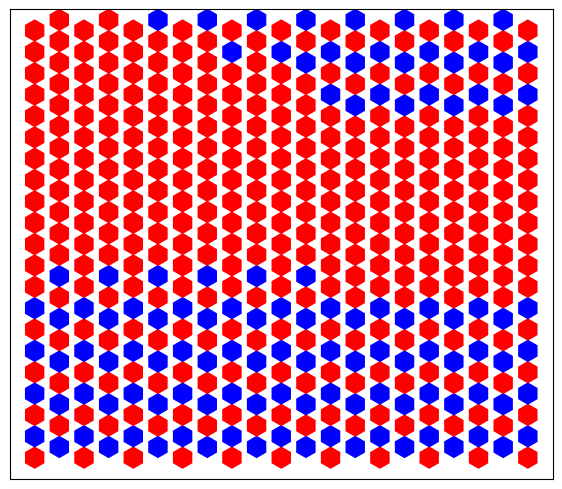

In [43]:
results_dict = {}
approx_ys = np.zeros(1)
time_eval = np.zeros(1)

Jc = 3

J_mat = np.array([[0,0,0,0,0],
                  [0,0,0,0,0],
                  [0,0,0,0,0]])

J_mat[0,1] = J_mat[0,3] = J_mat[1,0] = J_mat[1,4] = J_mat[2,1] = J_mat[2,3] = Jc

print(J_mat)

results_dict_tri = {}
approx_ys_tri = np.zeros(1)
time_eval = np.zeros(1)

np.random.seed(0)
tri_sim = Tri_IsingSim(N = 21, J_mat = J_mat, T = 0.2, save_trajectories=True, # Intializing the object
                       eqSteps = 150, mcSteps = 150,
                       prop = 0.5)  # Proportion of the sites occupied

tri_sim.performIsingSim()   # Running the sim

results_dict_tri[0] = {'sim': tri_sim.results,}
approx_ys_tri[0] = results_dict_tri[0]['sim']['SpecificHeat']
tri_sim.plot_config(results_dict_tri[0]['sim']['config'][-1])
plt.show()